In [11]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ GPU е наличен и memory growth е включен.")
else:
    print("❌ TensorFlow не вижда GPU. Ще тренира на CPU.")

TensorFlow version: 2.10.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU е наличен и memory growth е включен.


In [12]:
DATASET_CSV = r"D:\Магистър\Общ проект\dataset_mri_pet_labels.csv"

dataset_df = pd.read_csv(DATASET_CSV)

print("Dataset shape:", dataset_df.shape)
display(dataset_df.head())

print("Разпределение по диагноза:")
print(dataset_df["diagnosis"].value_counts())

Dataset shape: (458, 5)


,subject_id,mri_path,pet_path,diagnosis,label
0,002_S_0295,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
1,002_S_0413,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
2,002_S_0685,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
3,002_S_1261,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
4,002_S_1280,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0


Разпределение по диагноза:
diagnosis
CN    311
AD    147
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    dataset_df,
    test_size=0.20,
    random_state=42,
    stratify=dataset_df["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Train:", len(train_df))
print(train_df["diagnosis"].value_counts())
print()

print("Validation:", len(val_df))
print(val_df["diagnosis"].value_counts())
print()

print("Test:", len(test_df))
print(test_df["diagnosis"].value_counts())

Train: 292
diagnosis
CN    199
AD     93
Name: count, dtype: int64

Validation: 74
diagnosis
CN    50
AD    24
Name: count, dtype: int64

Test: 92
diagnosis
CN    62
AD    30
Name: count, dtype: int64


In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])  # CN = 0, AD = 1

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

print("Class weights:", class_weights)

Class weights: {0: 0.7336683417085427, 1: 1.5698924731182795}


In [15]:
BATCH_SIZE = 1
INPUT_SHAPE_SINGLE = (64, 64, 64, 1)

def downsample_volume(volume):
    return volume[::2, ::2, ::2]

def load_sample_dual(mri_path, pet_path, label):
    mri_path = mri_path.decode("utf-8")
    pet_path = pet_path.decode("utf-8")

    mri = np.load(mri_path).astype("float32")
    pet = np.load(pet_path).astype("float32")

    mri = downsample_volume(mri)
    pet = downsample_volume(pet)

    mri = np.expand_dims(mri, axis=-1)
    pet = np.expand_dims(pet, axis=-1)

    return mri, pet, np.float32(label)

def tf_load_sample_dual(mri_path, pet_path, label):
    mri, pet, y = tf.numpy_function(
        load_sample_dual,
        [mri_path, pet_path, label],
        [tf.float32, tf.float32, tf.float32]
    )

    mri.set_shape(INPUT_SHAPE_SINGLE)
    pet.set_shape(INPUT_SHAPE_SINGLE)
    y.set_shape(())

    return {"mri_input": mri, "pet_input": pet}, y

def make_dataset_dual(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["mri_path"].values,
        df["pet_path"].values,
        df["label"].values.astype("float32")
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_sample_dual, num_parallel_calls=1)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(1)

    return ds

train_ds = make_dataset_dual(train_df, shuffle=True)
val_ds = make_dataset_dual(val_df)
test_ds = make_dataset_dual(test_df)

for batch_x, batch_y in train_ds.take(1):
    print(batch_x.keys())
    print("MRI:", batch_x["mri_input"].shape)
    print("PET:", batch_x["pet_input"].shape)
    print("Y:", batch_y.shape)

dict_keys(['mri_input', 'pet_input'])
MRI: (1, 64, 64, 64, 1)
PET: (1, 64, 64, 64, 1)
Y: (1,)


In [16]:
import tensorflow as tf

def binary_focal_loss(gamma=2.0, alpha=0.65):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)

        return tf.reduce_mean(alpha_factor * modulating_factor * bce)

    return loss

In [17]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

def build_compact_branch(input_tensor, name):
    x = layers.Conv3D(8, 3, padding="same", use_bias=False, name=f"{name}_conv1")(input_tensor)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.MaxPooling3D(2, name=f"{name}_pool1")(x)

    x = layers.Conv3D(16, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    x = layers.MaxPooling3D(2, name=f"{name}_pool2")(x)

    x = layers.Conv3D(32, 3, padding="same", use_bias=False, name=f"{name}_conv3")(x)
    x = layers.BatchNormalization(name=f"{name}_bn3")(x)
    x = layers.Activation("relu", name=f"{name}_relu3")(x)
    x = layers.MaxPooling3D(2, name=f"{name}_pool3")(x)

    avg_pool = layers.GlobalAveragePooling3D(name=f"{name}_avg_pool")(x)
    max_pool = layers.GlobalMaxPooling3D(name=f"{name}_max_pool")(x)

    features = layers.Concatenate(name=f"{name}_avg_max_features")([avg_pool, max_pool])
    return features


def build_model4_dual_pooling(input_shape=(64, 64, 64, 1)):
    mri_input = layers.Input(shape=input_shape, name="mri_input")
    pet_input = layers.Input(shape=input_shape, name="pet_input")

    mri_features = build_compact_branch(mri_input, "mri")
    pet_features = build_compact_branch(pet_input, "pet")

    x = layers.Concatenate(name="fusion_features")([mri_features, pet_features])

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_64"
    )(x)
    x = layers.Dropout(0.35, name="dropout_1")(x)

    x = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_32"
    )(x)
    x = layers.Dropout(0.25, name="dropout_2")(x)

    output = layers.Dense(1, activation="sigmoid", name="classification_output")(x)

    model = models.Model(
        inputs=[mri_input, pet_input],
        outputs=output,
        name="Model4_DualBranch_AvgMaxPooling"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=7e-5),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

model4 = build_model4_dual_pooling()
model4.summary()

Model: "Model4_DualBranch_AvgMaxPooling"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 mri_input (InputLayer)         [(None, 64, 64, 64,  0           []                               
                                 1)]                                                              
                                                                                                  
 pet_input (InputLayer)         [(None, 64, 64, 64,  0           []                               
                                 1)]                                                              
                                                                                                  
 mri_conv1 (Conv3D)             (None, 64, 64, 64,   216         ['mri_input[0][0]']              
                                8)                                  

In [18]:
callbacks4 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "model4_dualbranch_avgmax.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [19]:
history4 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=callbacks4
)

Epoch 1/35
291/292 [============================>.] - ETA: 0s - loss: 1.0075 - accuracy: 0.6048 - precision: 0.3721 - sensitivity: 0.3441 - auc: 0.5198
Epoch 1: val_auc improved from -inf to 0.59125, saving model to model4_dualbranch_avgmax.keras
292/292 [==============================] - 20s 54ms/step - loss: 1.0052 - accuracy: 0.6062 - precision: 0.3721 - sensitivity: 0.3441 - auc: 0.5196 - val_loss: 0.6992 - val_accuracy: 0.5946 - val_precision: 0.4118 - val_sensitivity: 0.5833 - val_auc: 0.5912 - lr: 7.0000e-05
Epoch 2/35
292/292 [==============================] - ETA: 0s - loss: 0.7613 - accuracy: 0.6096 - precision: 0.3600 - sensitivity: 0.2903 - auc: 0.5374
Epoch 2: val_auc did not improve from 0.59125
292/292 [==============================] - 15s 52ms/step - loss: 0.7613 - accuracy: 0.6096 - precision: 0.3600 - sensitivity: 0.2903 - auc: 0.5374 - val_loss: 0.6452 - val_accuracy: 0.6757 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00 - val_auc: 0.5408 - lr: 7.0000e-05

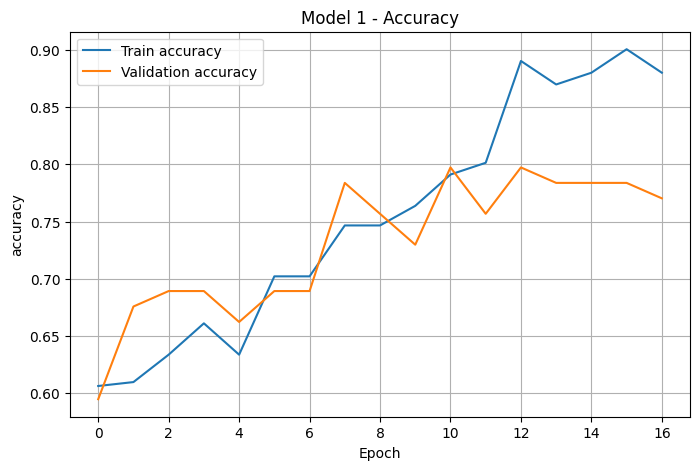

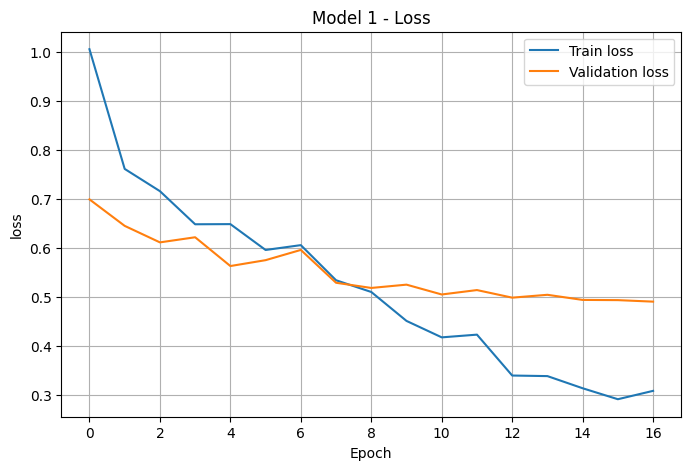

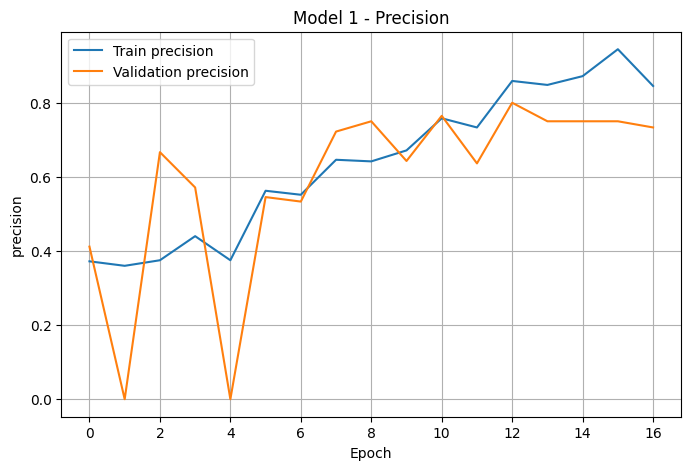

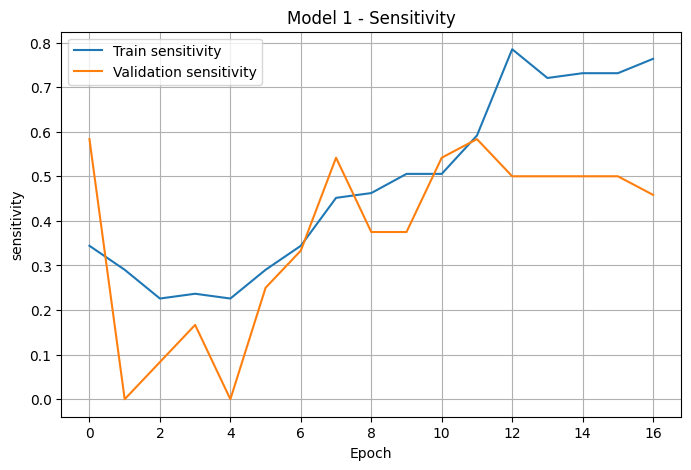

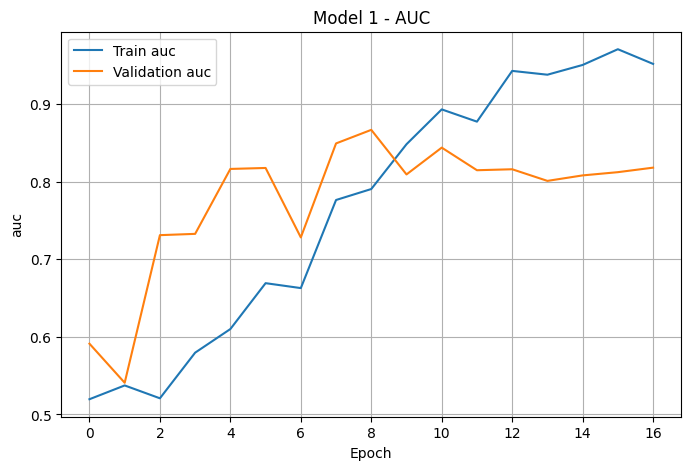

In [21]:
import matplotlib.pyplot as plt

def plot_metric(history, metric, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[metric], label=f"Train {metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"Validation {metric}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_metric(history4, "accuracy", "Model 1 - Accuracy", "model1_accuracy.png")
plot_metric(history4, "loss", "Model 1 - Loss", "model1_loss.png")
plot_metric(history4, "precision", "Model 1 - Precision", "model1_precision.png")
plot_metric(history4, "sensitivity", "Model 1 - Sensitivity", "model1_sensitivity.png")
plot_metric(history4, "auc", "Model 1 - AUC", "model1_auc.png")

In [22]:
test_results_4 = model4.evaluate(test_ds, verbose=1)

print("Model 4 Test results:")
for name, value in zip(model4.metrics_names, test_results_4):
    print(f"{name}: {value:.4f}")

92/92 [==============================] - 3s 35ms/step - loss: 0.5468 - accuracy: 0.7283 - precision: 0.7778 - sensitivity: 0.2333 - auc: 0.7876
Model 4 Test results:
loss: 0.5468
accuracy: 0.7283
precision: 0.7778
sensitivity: 0.2333
auc: 0.7876


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true_4 = []
y_prob_4 = []

for batch_x, y_batch in test_ds:
    preds = model4.predict(batch_x, verbose=0)
    y_prob_4.extend(preds.ravel())
    y_true_4.extend(y_batch.numpy().ravel())

y_true_4 = np.array(y_true_4).astype(int)
y_prob_4 = np.array(y_prob_4)

y_pred_4 = (y_prob_4 >= 0.5).astype(int)

cm4 = confusion_matrix(y_true_4, y_pred_4)

tn4, fp4, fn4, tp4 = cm4.ravel()

print("Model 4 Confusion Matrix:")
print(cm4)
print()
print(f"TN: {tn4}")
print(f"FP: {fp4}")
print(f"FN: {fn4}")
print(f"TP: {tp4}")
print()

print(classification_report(
    y_true_4,
    y_pred_4,
    target_names=["CN", "AD"],
    zero_division=0
))

Model 4 Confusion Matrix:
[[60  2]
 [23  7]]

TN: 60
FP: 2
FN: 23
TP: 7

              precision    recall  f1-score   support

          CN       0.72      0.97      0.83        62
          AD       0.78      0.23      0.36        30

    accuracy                           0.73        92
   macro avg       0.75      0.60      0.59        92
weighted avg       0.74      0.73      0.67        92



Model 4 Confusion Matrix:
[[60  2]
 [23  7]]

TN: 60
FP: 2
FN: 23
TP: 7

              precision    recall  f1-score   support

          CN       0.72      0.97      0.83        62
          AD       0.78      0.23      0.36        30

    accuracy                           0.73        92
   macro avg       0.75      0.60      0.59        92
weighted avg       0.74      0.73      0.67        92



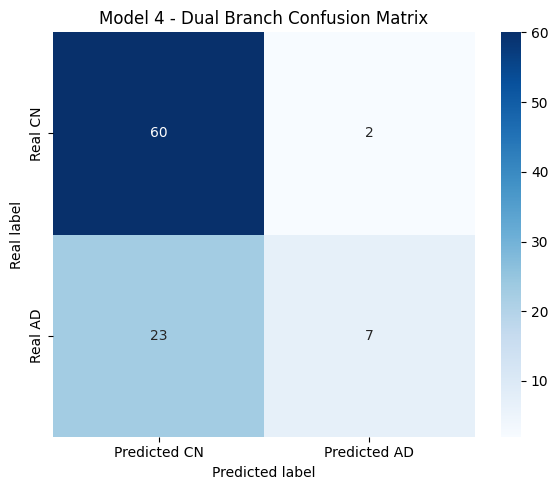

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Model 4 threshold
threshold = 0.50

y_pred_4 = (y_prob_4 >= threshold).astype(int)

cm4 = confusion_matrix(y_true_4, y_pred_4)

tn4, fp4, fn4, tp4 = cm4.ravel()

print("Model 4 Confusion Matrix:")
print(cm4)
print()
print(f"TN: {tn4}")
print(f"FP: {fp4}")
print(f"FN: {fn4}")
print(f"TP: {tp4}")
print()

print(classification_report(
    y_true_4,
    y_pred_4,
    target_names=["CN", "AD"],
    zero_division=0
))

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm4,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted CN", "Predicted AD"],
    yticklabels=["Real CN", "Real AD"]
)

plt.title("Model 4 - Dual Branch Confusion Matrix")
plt.ylabel("Real label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("model4_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
test_results = model4.evaluate(test_ds, verbose=1)

print("Test results:")
for name, value in zip(model4.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

92/92 [==============================] - 2s 22ms/step - loss: 0.5468 - accuracy: 0.7283 - precision: 0.7778 - sensitivity: 0.2333 - auc: 0.7876
Test results:
loss: 0.5468
accuracy: 0.7283
precision: 0.7778
sensitivity: 0.2333
auc: 0.7876
